# Credit Card Fraud Detection Using XGBoost

Credit card fraud is a serious financial problem where unauthorized transactions are made using stolen or compromised card information. With the rapid growth of online payments, detecting fraudulent transactions has become increasingly important.

In this notebook, we build an end-to-end machine learning pipeline to detect fraudulent credit card transactions using XGBoost.

The objective of this project is to classify transactions as:

- **0 → Normal Transaction**
- **1 → Fraudulent Transaction**

This is a **binary classification problem** with a highly **imbalanced dataset**, where fraudulent cases represent only a very small fraction of total transactions.

### 🔍 What this notebook covers:

- Understanding the dataset  
- Exploratory Data Analysis (EDA)  
- Handling class imbalance  
- Feature preprocessing  
- Training an XGBoost classifier  
- Model evaluation using multiple metrics  
- Confusion Matrix and ROC Curve  
- Feature importance analysis  

By the end of this notebook, we will have a complete fraud detection pipeline and understand how XGBoost performs on real-world imbalanced data.

---

### 📌 Goal

Build a reliable machine learning model that can accurately identify fraudulent transactions while minimizing false negatives (missed fraud cases).

This project focuses on practical ML concepts used in industry-level fraud detection systems.

## Section 2 — Dataset Overview

The dataset used in this project contains real credit card transactions made by European cardholders over a two-day period.

### 📄 Dataset Characteristics

- Total transactions: ~284,000  
- Fraudulent transactions: very small fraction (~0.17%)  
- Target column: `Class`
    - `0` → Normal transaction  
    - `1` → Fraudulent transaction  

Most input features (`V1` to `V28`) are anonymized and transformed using **Principal Component Analysis (PCA)** to protect sensitive user information.

Additional columns:

- `Time` → Seconds elapsed between each transaction and the first transaction  
- `Amount` → Transaction amount  
- `Class` → Target label  

This dataset is **highly imbalanced**, which makes fraud detection a challenging real-world machine learning problem.

In the next step, we will load the dataset and perform initial inspection.

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("/kaggle/input/creditcardfraud/creditcard.csv")

# Show first 5 rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
# Dataset shape
print("Shape:", df.shape)

# Column names
print("\nColumns:\n", df.columns)

# Dataset info
df.info()

Shape: (284807, 31)

Columns:
 Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non

In [3]:
# Check missing values
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [4]:
# Statistical summary
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


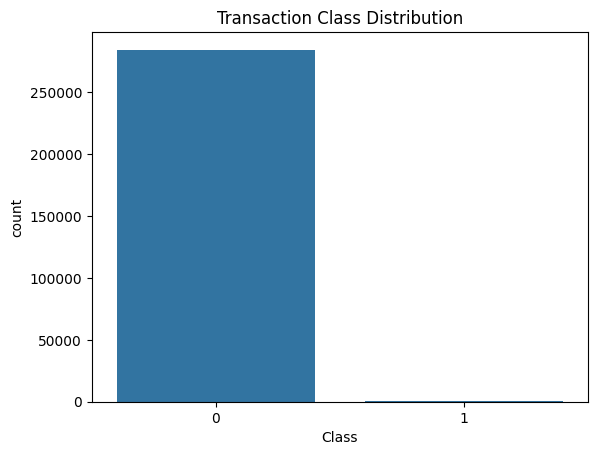

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count plot of target variable
sns.countplot(x='Class', data=df)
plt.title("Transaction Class Distribution")
plt.show()

### 📊 Class Imbalance Observation

From the visualization above, we can clearly see that the dataset is **highly imbalanced**.

- Normal transactions (Class = 0) dominate the dataset  
- Fraudulent transactions (Class = 1) are extremely rare  

This means that **accuracy alone is not a reliable metric**, because a model could achieve very high accuracy simply by predicting every transaction as normal.

Therefore, in later sections, we will focus on metrics such as:

- Precision  
- Recall  
- F1-score  
- ROC-AUC  

which are more meaningful for fraud detection problems.

In [6]:
# Separate features and target

X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (284807, 30)
Target shape: (284807,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (227845, 30)
Testing set: (56962, 30)


### ✂ Train-Test Split

The dataset is split into:

- 80% Training data  
- 20% Testing data  

Stratification is used to preserve the original class distribution in both sets.

The model will learn patterns from the training data and will be evaluated on unseen test data.

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X[['Amount', 'Time']] = scaler.fit_transform(X[['Amount', 'Time']])

### 🔄 Feature Scaling

The features `V1` to `V28` are already scaled using PCA.

However, `Amount` and `Time` are not standardized.

We apply **Standard Scaling** to these columns so that all features are on a similar scale.  
This helps improve model stability and convergence during training.

In [9]:
from xgboost import XGBClassifier

In [10]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

In [11]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [12]:
y_pred = xgb_model.predict(X_test)

### 🤖 Model Training

We trained an XGBoost classifier using the training dataset.

XGBoost is a powerful gradient boosting algorithm that builds an ensemble of decision trees to improve prediction accuracy.

After training, predictions are generated on the unseen test dataset.

In [13]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9995259997893332

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.83      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962



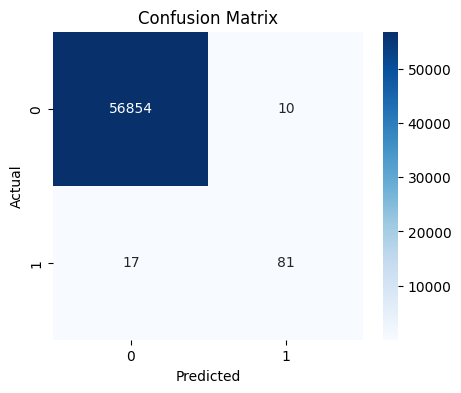

In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### 📊 Model Evaluation Results

Accuracy alone is not sufficient for fraud detection due to class imbalance.

Therefore, we analyze:

- **Precision** – How many predicted frauds were actually fraud  
- **Recall** – How many real frauds were correctly detected  
- **F1-score** – Balance between precision and recall  

The confusion matrix shows:

- True Negatives (normal correctly classified)
- False Positives (normal predicted as fraud)
- False Negatives (fraud missed)
- True Positives (fraud correctly detected)

In fraud detection, **recall for Class 1 is especially important**, since missing a fraudulent transaction can have serious consequences.

In [15]:
from sklearn.metrics import roc_curve, auc

# Probability of positive class (fraud = 1)
y_probs = xgb_model.predict_proba(X_test)[:, 1]

In [16]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

AUC Score: 0.9786081075649169


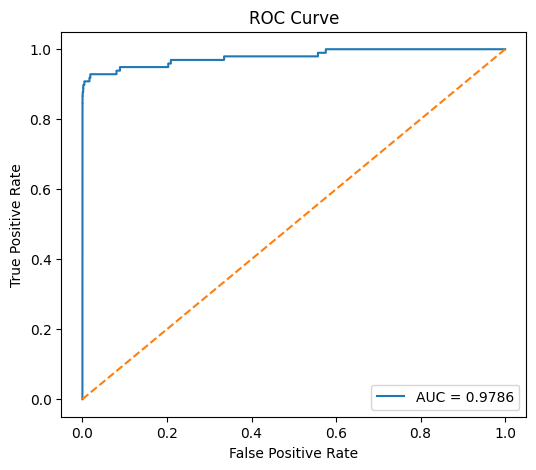

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### 📈 ROC Curve and AUC

The ROC curve shows the trade-off between:

- True Positive Rate (Recall)
- False Positive Rate

AUC (Area Under Curve) summarizes this performance into a single value:

- AUC = 0.5 → Random guessing  
- AUC = 1.0 → Perfect classifier  

A higher AUC indicates better ability to distinguish between fraudulent and normal transactions.

ROC-AUC is especially useful for imbalanced datasets like fraud detection.

In [18]:
# Get feature importance scores
importance = xgb_model.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
})

# Sort values
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

feature_importance_df.head(10)

,Feature,Importance
17,V17,0.678920
12,V12,0.130617
14,V14,0.022121
4,V4,0.016541
10,V10,0.012036
3,V3,0.008878
7,V7,0.006953
29,Amount,0.006951
28,V28,0.006773
21,V21,0.006604


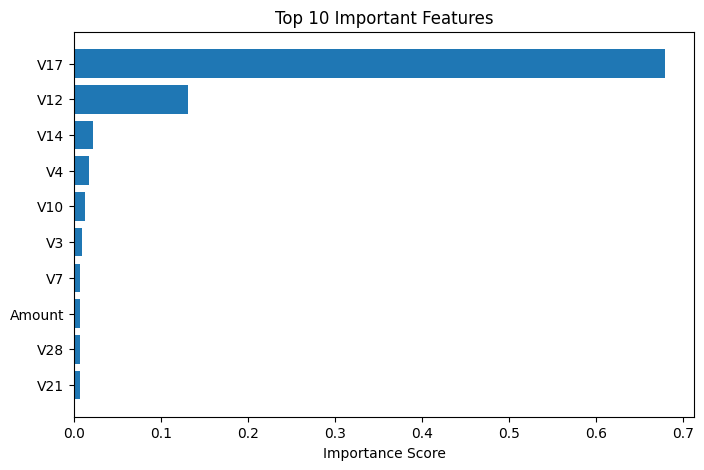

In [19]:
import matplotlib.pyplot as plt

top_features = feature_importance_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Top 10 Important Features")
plt.show()

### 🔍 Feature Importance Analysis

XGBoost provides feature importance scores that indicate how much each feature contributes to the model's predictions.

From the chart above, we can see which variables play the most significant role in detecting fraudulent transactions.

Even though the original features are anonymized (V1–V28), the model identifies certain transformed components as highly predictive.

Feature importance helps in:

- Understanding model behavior  
- Identifying influential variables  
- Improving future feature engineering  

## 🏁 Final Conclusion

In this project, we built an end-to-end fraud detection pipeline using XGBoost.

### Key Highlights:

- The dataset is highly imbalanced, making evaluation metrics beyond accuracy essential.
- XGBoost performed effectively in distinguishing fraudulent transactions.
- ROC-AUC score indicates strong classification capability.
- Feature importance analysis reveals which transformed features contribute most to predictions.

### Possible Improvements:

- Hyperparameter tuning (GridSearch / RandomSearch)
- Using SMOTE to handle class imbalance
- Cross-validation for more robust evaluation
- Comparing with other models (Logistic Regression, Random Forest)

This project demonstrates a practical application of machine learning in financial fraud detection using a structured and professional workflow.